In [3]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds

from tensorflow.keras import layers

Download a dataset

This tutorial uses the tf_flowers dataset. For convenience, download the dataset using TensorFlow Datasets. If you would like to learn about other ways of importing data, check out the load images tutorial.


In [4]:
(train_ds, val_ds, test_ds), metadata = tfds.load(
    'tf_flowers',
    split=['train[:80%]', 'train[80%:90%]', 'train[90%:]'],
    with_info=True,
    as_supervised=True,
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/tf_flowers/incomplete.LI02GW_3.0.1/tf_flowers-train.tfrecord*...:   0%|   …

Dataset tf_flowers downloaded and prepared to /root/tensorflow_datasets/tf_flowers/3.0.1. Subsequent calls will reuse this data.


The flowers dataset has five classes.

In [5]:
num_classes = metadata.features['label'].num_classes
print(num_classes)

5


Let's retrieve an image from the dataset and use it to demonstrate data augmentation.


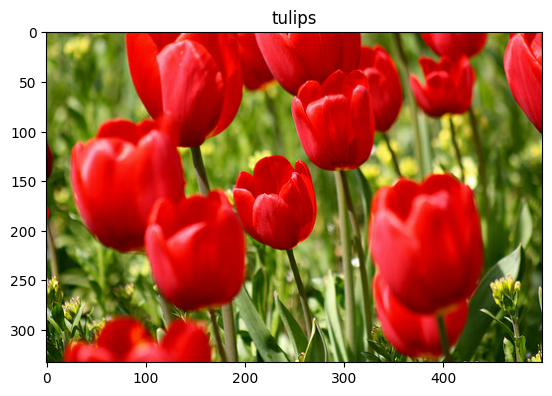

In [7]:
get_label_name = metadata.features['label'].int2str

image, label = next(iter(train_ds))
_ = plt.imshow(image)
_ = plt.title(get_label_name(label))

# Use Keras preprocessing layers

Resizing and rescaling

You can use the Keras preprocessing layers to resize your images to a consistent shape (with tf.keras.layers.Resizing), and to rescale pixel values (with tf.keras.layers.Rescaling).


In [8]:
IMG_SIZE = 180

resize_and_rescale = tf.keras.Sequential([
  layers.Resizing(IMG_SIZE, IMG_SIZE),
  layers.Rescaling(1./255)
])

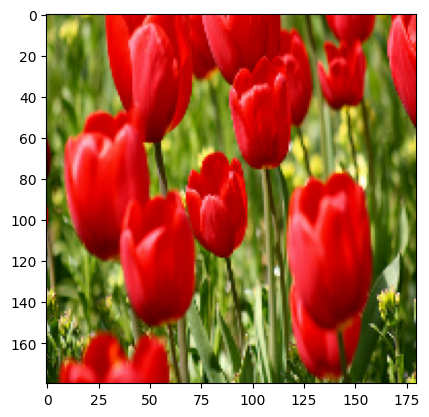

In [9]:
result = resize_and_rescale(image)
_ = plt.imshow(result)

In [10]:
# Verify that the pixels are in the [0, 1] range:


print("Min and max pixel values:", result.numpy().min(), result.numpy().max())

Min and max pixel values: 0.0 1.0


# Data augmentation

You can use the Keras preprocessing layers for data augmentation as well, such as tf.keras.layers.RandomFlip and tf.keras.layers.RandomRotation.

Let's create a few preprocessing layers and apply them repeatedly to the same image.



In [13]:
data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.2),
  layers.RandomZoom(0.2),
  layers.RandomContrast(0.2),
])

In [15]:
# Add the image to a batch.
image = tf.cast(tf.expand_dims(image, 0), tf.float32)

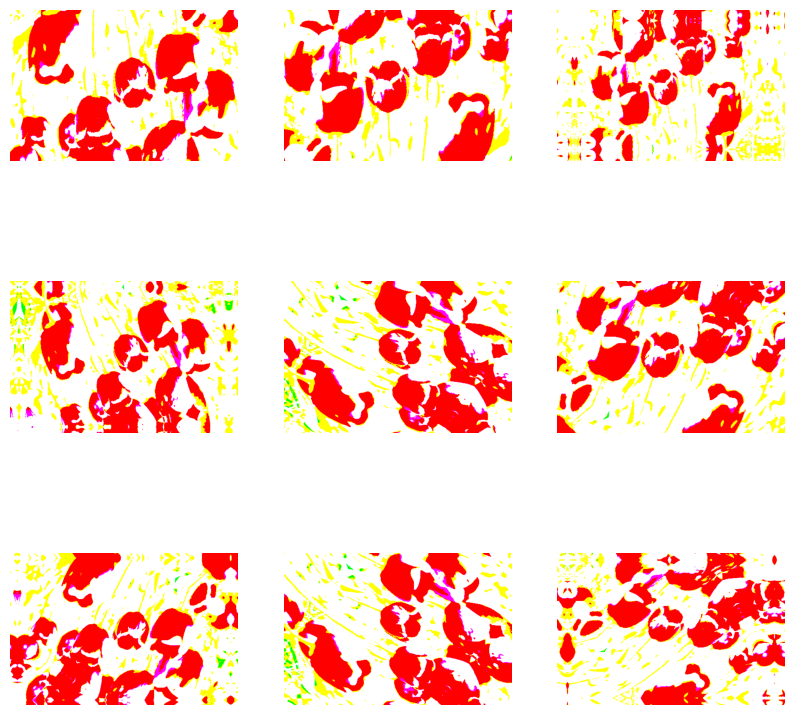

In [16]:
plt.figure(figsize=(10, 10))
for i in range(9):
  augmented_image = data_augmentation(image)
  ax = plt.subplot(3, 3, i + 1)
  plt.imshow(augmented_image[0])
  plt.axis("off")

In [19]:
augmented_image = data_augmentation(image)

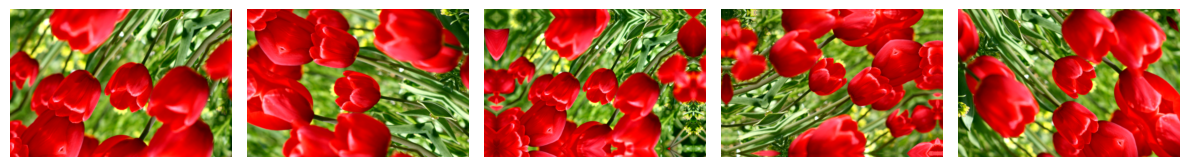

In [25]:
import matplotlib.pyplot as plt

augmented_images = []

for i in range(5):
    aug_img = tf.squeeze(data_augmentation(image), axis=0)
    augmented_images.append(aug_img)
    tf.keras.utils.save_img(f"aug_{i}.jpg", aug_img)

# Plot all images
plt.figure(figsize=(12,6))

for i, img in enumerate(augmented_images):
    plt.subplot(1, 5, i+1)
    plt.imshow(img.numpy().astype("uint8"))
    plt.axis("off")

plt.tight_layout()
plt.show()

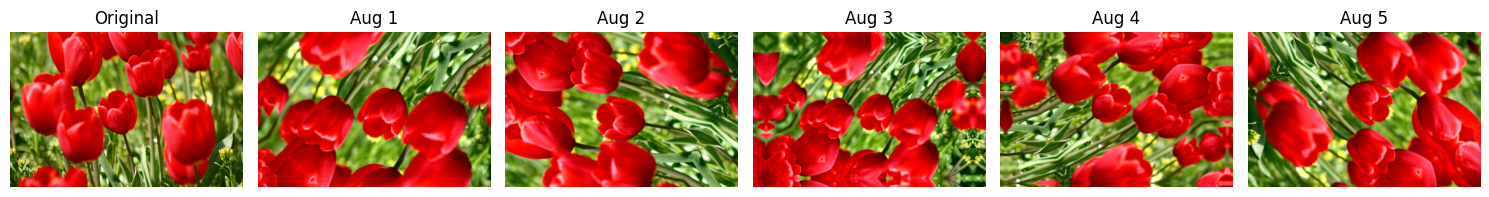

In [26]:
plt.figure(figsize=(15,6))

# Original
plt.subplot(1,6,1)
plt.imshow(tf.squeeze(image, axis=0).numpy().astype("uint8"))
plt.title("Original")
plt.axis("off")

# Augmented
for i, img in enumerate(augmented_images):
    plt.subplot(1,6,i+2)
    plt.imshow(img.numpy().astype("uint8"))
    plt.title(f"Aug {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
model = tf.keras.Sequential([
  # Add the preprocessing layers you created earlier.
  resize_and_rescale,
  data_augmentation,
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  # Rest of your model.
])

ValueError: Exception encountered when calling Sequential.call().

[1mInput 0 of layer "functional_1" is incompatible with the layer: expected shape=(None, 333, 500, 3), found shape=(180, 180, 3)[0m

Arguments received by Sequential.call():
  • args=('<KerasTensor shape=(180, 180, 3), dtype=float32, sparse=False, ragged=False, name=keras_tensor_9>',)
  • kwargs={'mask': 'None'}